In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Load dataset
df = pd.read_csv('data5.csv')


In [157]:
print(df)

     CustomerID   Genre  Age  Annual Income  Spending Score
0             1    Male   19          19000               0
1             2    Male   35          20000               0
2             3  Female   26          43000               0
3             4  Female   27          57000               0
4             5    Male   19          76000               0
..          ...     ...  ...            ...             ...
194         195    Male   28          89000               0
195         196    Male   34          43000               0
196         197  Female   30          79000               0
197         198  Female   20          36000               0
198         199    Male   26          80000               0

[199 rows x 5 columns]


In [159]:
# Drop 'Gender' column
df1 = df.drop("Genre", axis=1)

# Define features and target variable
y = df1.iloc[:, -1].values  # Target variable
x = df1.iloc[:, :-1].values  # Feature set

In [161]:
# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=2)


In [163]:
# Train Logistic Regression model
LR = LogisticRegression()
LR.fit(x_train, y_train)

LogisticRegression()

In [165]:
# Compute confusion matrix
y_pred = LR.predict(x_test)


In [172]:
cm= confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[45  1]
 [ 1  3]]


ravel() is a function in NumPy that "flattens" an array — meaning it converts a multi-dimensional array into a one-dimensional array.

In [177]:
TN, FP, FN, TP = cm.ravel()

# Calculate metrics
accuracy = (TN + TP) * 100 / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = (2 * precision * recall) / (precision + recall)   #When both false positives and false negatives matter.
specificity = TN / (TN + FP)     # True Negative Rate (TNR)

# Display metrics
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}")
print(f"Specificity: {specificity:.2f}")


Accuracy: 96.00%
Precision: 0.75
Recall: 0.75
F1 Score: 0.75
Specificity: 0.98


In [185]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)  
x_test = sc.transform(x_test) 

print("Feature1 = CustomerID")
print("Feature2 = Age")
print("Feature3 = Annual Income")
print("Enter values for the following features:")

input_features = []

for i in range(x_train.shape[1]):
    val = float(input(f"Feature {i+1}: "))
    input_features.append(val)

# Convert input into numpy array and reshape
#input_array = np.array(input_features).reshape(1, -1)

# Make prediction
scaled_input = sc.transform([input_features])  # Scale the input values
prediction = LR.predict(scaled_input)[0]
print(f"Predicted Output: {prediction}")

Feature1 = CustomerID
Feature2 = Age
Feature3 = Annual Income
Enter values for the following features:


Feature 1:  4
Feature 2:  67
Feature 3:  5643246


Predicted Output: 1



 
purchase the product (output 1) or not purchase the product (output 0).



In [151]:
df1.columns[:-1]  #excludeing target var

Index(['CustomerID', 'Age', 'Annual Income'], dtype='object')

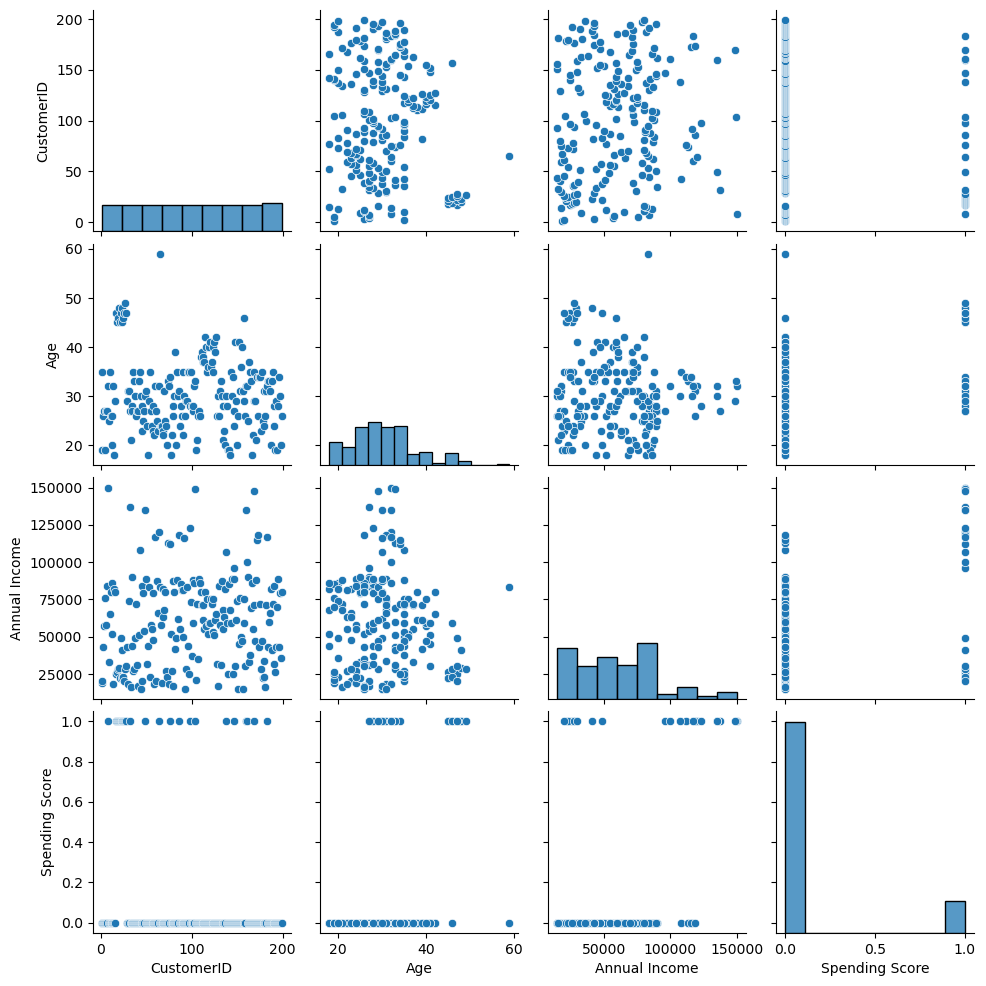

In [153]:
sns.pairplot(df)